<a href="https://colab.research.google.com/github/Hamerson-jhoel/Teoria_de_senales/blob/main/QUIZ2/QUIZ2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Hamerson piarpuezan

se genera y analiza dos señales aleatorias llamadas **símbolo 0** y **símbolo 1**, permitiendo modificar sus características mediante *sliders*.  
El análisis incluye:  
- Señales en el tiempo  
- Autocorrelación  
- Zoom de autocorrelación  
- Densidad espectral de potencia (PSD)  
- Espectrogramas  
- Actualización en tiempo real

---

## 1. Generación del tiempo y envolventes

Se define la duración del símbolo como \(T_{\text{symbol}} = 1\) segundo y la frecuencia de muestreo como \(F_s = 1000\) Hz.  
El vector de tiempo es:

$$ t = \frac{n}{F_s}, \quad n = 0,1,\ldots,N-1 $$

Se construye un **envolvente gaussiano**:

$$
\text{env}_0(t) = \exp\left( -\frac{1}{2}\left(\frac{t - T_{\text{symbol}}/2}{\sigma}\right)^2 \right)
$$

Luego se normaliza a su valor máximo. El complemento es:

$$ \text{env}_1(t) = 1 - \text{env}_0(t) $$

---

## 2. Filtro pasa-bajas

Para modelar procesos con distinto ancho de banda, se usa un filtro Butterworth:

$$ H(s) = \frac{1}{\sqrt{1 + \left(\frac{\omega}{\omega_c}\right)^{2n}}} $$

donde \( \omega_c \) depende del valor del *slider*:

- Para símbolo 0:

$$ f_c = 50 + 200\,D_0 $$

- Para símbolo 1:

$$ f_c = 30 + 150\,D_1 $$

---

## 3. Generación de símbolo 0

1. Se genera ruido blanco:

$$ x[n] \sim \mathcal{N}(0,1) $$

2. Se filtra con el pasa-bajas.

3. Se remueve la media para evitar componente DC:

$$ x[n] \leftarrow x[n] - \mu_x $$

4. Se multiplica por el envolvente:

$$ s_0(t) = D_0 \,\text{env}_0(t)\, x(t) $$

5. Se normaliza por desviación estándar:

$$ s_0(t) \leftarrow \frac{s_0(t)}{\sigma_{s_0}} $$

---

## 4. Generación de símbolo 1

Mismo proceso, pero usando el envolvente complementario:

$$ s_1(t) = D_1 \,\text{env}_1(t)\, x(t) $$

---

## 5. Autocorrelación

Para cada señal se calcula la autocorrelación **sin sesgo**:

$$
R(\tau) = \frac{1}{N} \sum_{n=0}^{N-1-\tau} x[n]\,x[n+\tau]
$$

Se normaliza por \(R(0)\):

$$ \tilde{R}(\tau) = \frac{R(\tau)}{R(0)} $$

---

## 6. Densidad espectral de potencia (PSD)

Se usa FFT con ventana de Hann:

$$ X[k] = \text{FFT}\{\; x[n] w[n] \;\} $$

La PSD es:

$$ S(f) = |X(f)|^2 $$

y se pasa a dB:

$$ S_{\text{dB}} = 10\log_{10}(S + 10^{-12}) $$

---

## 7. Espectrograma con `scipy.signal.spectrogram`

La representación tiempo-frecuencia se calcula como:

$$
\text{Sxx}(t,f) = |\text{STFT}\{x(t)\}|^2
$$

Luego se convierte a dB y se normaliza:

$$
S_{\text{dB}} = 10\log_{10}(\text{Sxx} + 10^{-12}) - \max(\cdot)
$$

---

## 8. Sliders y actualización

Cuando el usuario mueve \(D_0\) o \(D_1\):

- Se regeneran ambos símbolos  
- Se recalculan autocorrelaciones  
- Se recalcula PSD  
- Se recalculan espectrogramas  
- Se actualizan todas las gráficas

Esto permite **visualizar en tiempo real** cómo el ancho de banda y la variabilidad afectan todas las métricas estadísticas.




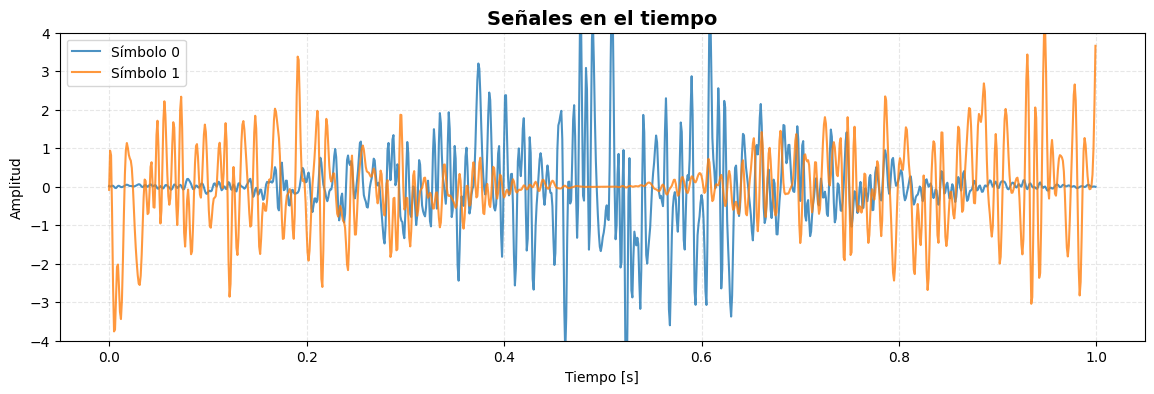

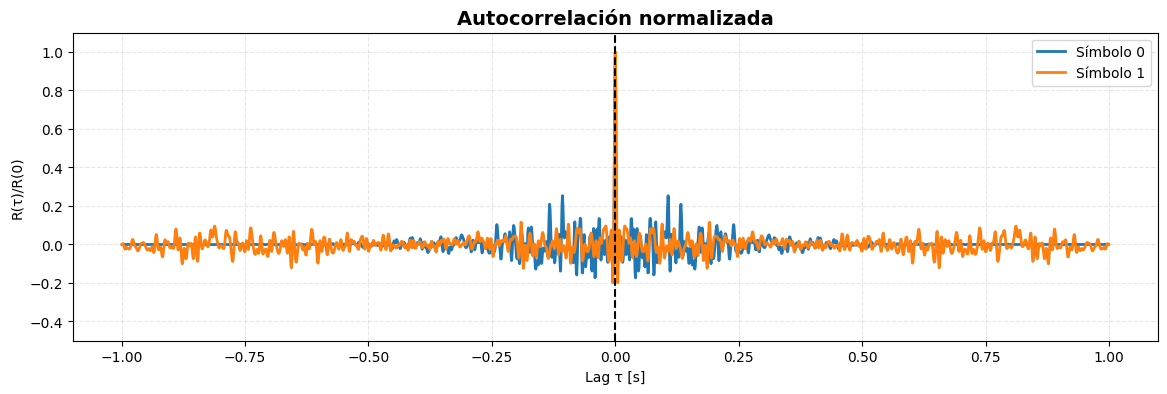

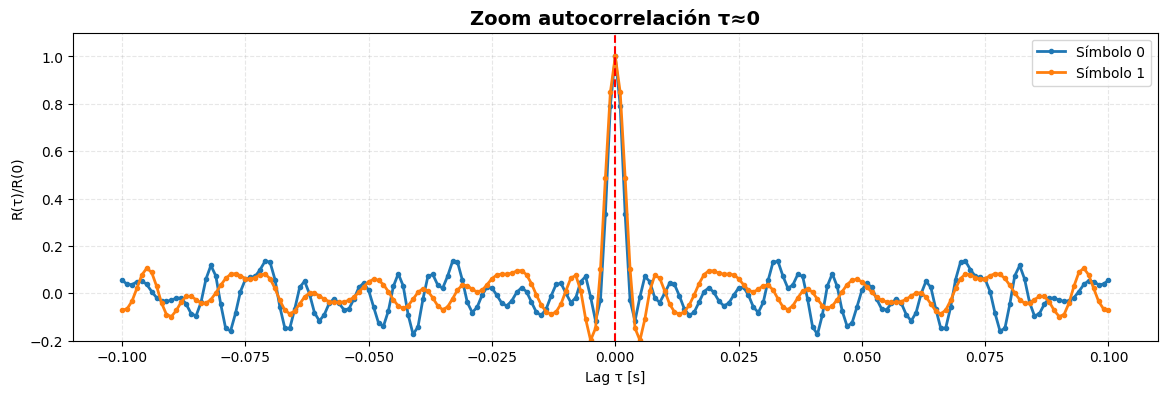

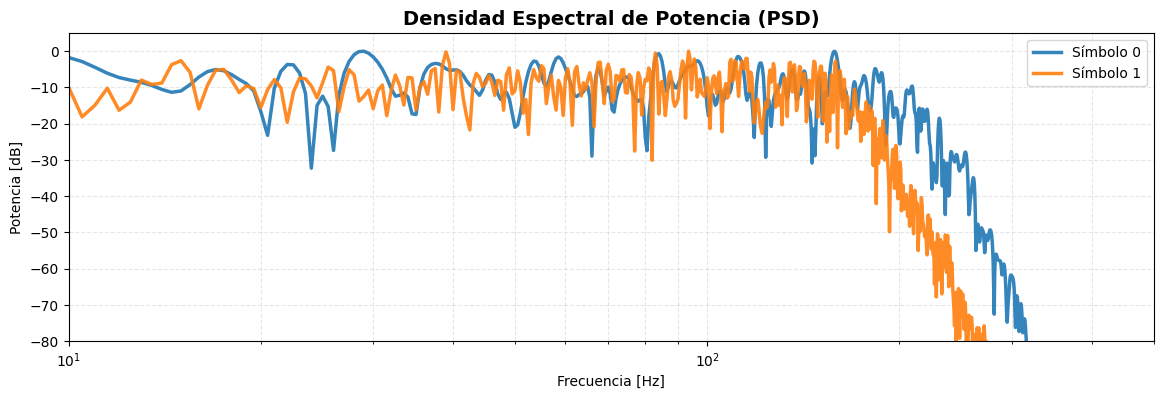

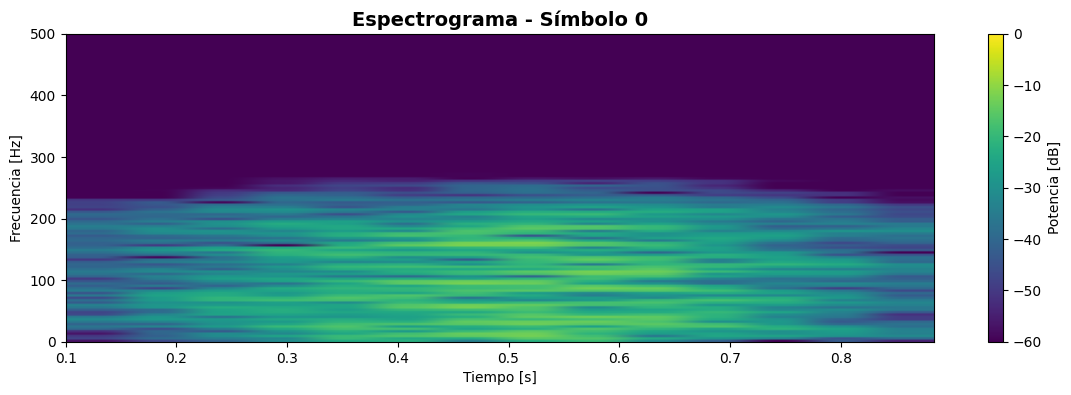

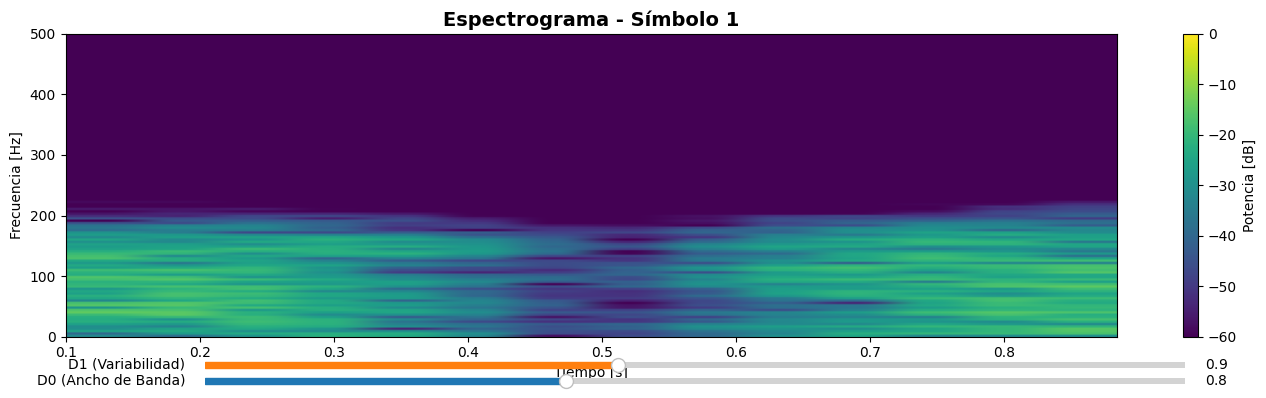

In [19]:
import torch
import math
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider
import numpy as np
from scipy import signal

# ================= CONFIGURACIÓN =================
device = torch.device("cpu")
torch.set_default_dtype(torch.float64)

Fs = 1000.0
T_symbol = 1.0
N = int(Fs * T_symbol)
Ts = 1/Fs
t = torch.arange(0, N, device=device) * Ts

center = T_symbol/2
sigma_env = T_symbol/6
env0 = torch.exp(-0.5*((t-center)/sigma_env)**2)
env0 /= env0.max()
env1 = 1.0 - env0

# ================= FUNCIONES =================
def apply_lowpass_filter(signal_data, cutoff_freq, fs, order=5):
    """Aplica un filtro pasa-bajas Butterworth"""
    nyquist = fs / 2
    normal_cutoff = cutoff_freq / nyquist
    b, a = signal.butter(order, normal_cutoff, btype='low', analog=False)
    filtered = signal.filtfilt(b, a, signal_data)
    return np.ascontiguousarray(filtered)  # Fix para stride negativo

def generate_symbol0(D0_val, seed=None):
    if seed is not None:
        torch.manual_seed(seed)

    # Proceso base con varianza controlada por D0
    noise = torch.randn(N, device=device)

    # El ancho de banda se controla con D0
    # D0 más grande = más variabilidad = más ancho de banda
    cutoff_freq = 50 + D0_val * 200  # Rango: 50-450 Hz

    # Generar señal base
    signal_base = noise

    # Aplicar filtro pasa-bajas
    signal_filtered = apply_lowpass_filter(signal_base.cpu().numpy(), cutoff_freq, Fs, order=6)
    signal_filtered = torch.from_numpy(signal_filtered).to(device)

    # CRÍTICO: Remover media para eliminar componente DC
    signal_filtered = signal_filtered - signal_filtered.mean()

    # Aplicar envelope gaussiano
    symbol0 = signal_filtered * env0 * D0_val

    # Remover media nuevamente después del envelope
    symbol0 = symbol0 - symbol0.mean()

    # Normalizar solo por desviación estándar para mantener centrado en 0
    if symbol0.std() > 0:
        symbol0 = symbol0 / symbol0.std()

    return symbol0

def generate_symbol1(D1_val, seed=None):
    if seed is not None:
        torch.manual_seed(seed + 1000)

    # Proceso determinístico modulado por ruido
    noise = torch.randn(N, device=device)

    # D1 controla la desviación del nivel constante
    cutoff_freq = 30 + D1_val * 150  # Rango: 30-330 Hz

    # Señal base de ruido
    signal_base = noise

    # Aplicar filtro pasa-bajas para suavizar
    signal_filtered = apply_lowpass_filter(signal_base.cpu().numpy(), cutoff_freq, Fs, order=6)
    signal_filtered = torch.from_numpy(signal_filtered).to(device)

    # CRÍTICO: Remover media para eliminar componente DC
    signal_filtered = signal_filtered - signal_filtered.mean()

    # Aplicar envelope complementario
    symbol1 = signal_filtered * env1 * D1_val

    # Remover media nuevamente después del envelope
    symbol1 = symbol1 - symbol1.mean()

    # Normalizar solo por desviación estándar
    if symbol1.std() > 0:
        symbol1 = symbol1 / symbol1.std()

    return symbol1

def autocorrelation_unbiased(x):
    """Autocorrelación calculada correctamente sin componente DC"""
    # CRÍTICO: Remover la media para eliminar componente DC
    x_centered = x - x.mean()
    N_sig = len(x_centered)
    R = torch.zeros(2*N_sig-1, dtype=torch.float64, device=x.device)

    for lag in range(N_sig):
        if lag == 0:
            R[N_sig-1] = torch.sum(x_centered * x_centered) / N_sig
        else:
            # Autocorrelación simétrica
            R[N_sig-1-lag] = torch.sum(x_centered[lag:] * x_centered[:N_sig-lag]) / N_sig
            R[N_sig-1+lag] = torch.sum(x_centered[:N_sig-lag] * x_centered[lag:]) / N_sig

    return R

def compute_autocorr(symbol):
    R = autocorrelation_unbiased(symbol)
    # Normalizar por el valor en lag=0
    if R[N-1] != 0:
        R = R / R[N-1]
    lags = torch.arange(-(N-1), N, device=device) * Ts
    return R, lags

def compute_spectrum(symbol):
    """Calcula la PSD mostrando claramente el efecto del filtro"""
    # Usar FFT directa con ventana para mejor visualización
    window = np.hanning(N)
    signal_windowed = symbol.cpu().numpy() * window

    # FFT
    fft_result = np.fft.rfft(signal_windowed, n=N*2)  # Zero-padding para mejor resolución
    freqs = np.fft.rfftfreq(N*2, Ts)

    # Magnitud al cuadrado (potencia)
    S = np.abs(fft_result)**2

    # Convertir a dB
    S_db = 10*np.log10(S + 1e-12)
    S_db = S_db - S_db.max()  # Normalizar al pico

    return freqs, S_db

# ================= CONFIGURACIÓN INICIAL =================
D0_init = 0.8
D1_init = 0.9
current_seed = 42

torch.manual_seed(current_seed)
symbol0 = generate_symbol0(D0_init, seed=current_seed)
symbol1 = generate_symbol1(D1_init, seed=current_seed)

R0, lags = compute_autocorr(symbol0)
R1, _ = compute_autocorr(symbol1)

f0, S0_db = compute_spectrum(symbol0)
f1, S1_db = compute_spectrum(symbol1)

# ================= FIGURAS =================
# --- Tiempo ---
fig_time, ax_time = plt.subplots(figsize=(14,4))
line0_time, = ax_time.plot(t.cpu(), symbol0.cpu(), label="Símbolo 0", linewidth=1.5, alpha=0.8)
line1_time, = ax_time.plot(t.cpu(), symbol1.cpu(), label="Símbolo 1", linewidth=1.5, alpha=0.8)
ax_time.set_title("Señales en el tiempo", fontsize=14, fontweight='bold')
ax_time.set_xlabel("Tiempo [s]")
ax_time.set_ylabel("Amplitud")
ax_time.grid(True, linestyle="--", alpha=0.3)
ax_time.legend()
ax_time.set_ylim([-4, 4])

# --- Autocorrelación ---
fig_corr, ax_corr = plt.subplots(figsize=(14,4))
line0_corr, = ax_corr.plot(lags.cpu(), R0.cpu(), label="Símbolo 0", linewidth=2)
line1_corr, = ax_corr.plot(lags.cpu(), R1.cpu(), label="Símbolo 1", linewidth=2)
ax_corr.axvline(0, color="black", linestyle="--", linewidth=1.5)
ax_corr.set_title("Autocorrelación normalizada", fontsize=14, fontweight='bold')
ax_corr.set_xlabel("Lag τ [s]")
ax_corr.set_ylabel("R(τ)/R(0)")
ax_corr.grid(True, linestyle="--", alpha=0.3)
ax_corr.legend()
ax_corr.set_ylim([-0.5, 1.1])

# --- Zoom autocorrelación ---
zoom_range = 0.1
fig_zoom, ax_zoom = plt.subplots(figsize=(14,4))
mask_zoom = (lags>=-zoom_range)&(lags<=zoom_range)
line0_zoom, = ax_zoom.plot(lags[mask_zoom].cpu(), R0[mask_zoom].cpu(), label="Símbolo 0", linewidth=2, marker='o', markersize=3)
line1_zoom, = ax_zoom.plot(lags[mask_zoom].cpu(), R1[mask_zoom].cpu(), label="Símbolo 1", linewidth=2, marker='o', markersize=3)
ax_zoom.axvline(0,color='red',linestyle='--',linewidth=1.5)
ax_zoom.set_title("Zoom autocorrelación τ≈0", fontsize=14, fontweight='bold')
ax_zoom.set_xlabel("Lag τ [s]")
ax_zoom.set_ylabel("R(τ)/R(0)")
ax_zoom.grid(True, linestyle="--", alpha=0.3)
ax_zoom.legend()
ax_zoom.set_ylim([-0.2, 1.1])

# --- PSD (Power Spectral Density) ---
fig_fft, ax_fft = plt.subplots(figsize=(14,4))
line0_fft, = ax_fft.plot(f0, S0_db, label="Símbolo 0", linewidth=2.5, alpha=0.9)
line1_fft, = ax_fft.plot(f1, S1_db, label="Símbolo 1", linewidth=2.5, alpha=0.9)
ax_fft.set_title("Densidad Espectral de Potencia (PSD)", fontsize=14, fontweight='bold')
ax_fft.set_xlabel("Frecuencia [Hz]")
ax_fft.set_ylabel("Potencia [dB]")
ax_fft.set_xscale('log')
ax_fft.grid(True, linestyle="--", alpha=0.3, which='both')
ax_fft.legend()
ax_fft.set_xlim([10, Fs/2])
ax_fft.set_ylim([-80, 5])

# --- Espectrograma Símbolo 0 ---
fig_spec0, ax_spec0 = plt.subplots(figsize=(14,4))
spec0 = ax_spec0.specgram(symbol0.cpu().numpy(), Fs=Fs, NFFT=256, noverlap=200, cmap='viridis', scale='dB', vmin=-60, vmax=0)
ax_spec0.set_title("Espectrograma - Símbolo 0", fontsize=14, fontweight='bold')
ax_spec0.set_xlabel("Tiempo [s]")
ax_spec0.set_ylabel("Frecuencia [Hz]")
ax_spec0.set_ylim([0, Fs/2])
plt.colorbar(spec0[3], ax=ax_spec0, label='Potencia [dB]')

# --- Espectrograma Símbolo 1 ---
fig_spec1, ax_spec1 = plt.subplots(figsize=(14,4))
spec1 = ax_spec1.specgram(symbol1.cpu().numpy(), Fs=Fs, NFFT=256, noverlap=200, cmap='viridis', scale='dB', vmin=-60, vmax=0)
ax_spec1.set_title("Espectrograma - Símbolo 1", fontsize=14, fontweight='bold')
ax_spec1.set_xlabel("Tiempo [s]")
ax_spec1.set_ylabel("Frecuencia [Hz]")
ax_spec1.set_ylim([0, Fs/2])
plt.colorbar(spec1[3], ax=ax_spec1, label='Potencia [dB]')

plt.tight_layout()

# ================= SLIDERS =================
ax_D0 = plt.axes([0.15,0.02,0.7,0.03])
slider_D0 = Slider(ax_D0, 'D0 (Ancho de Banda)', 0.1, 2.0, valinit=D0_init, valstep=0.05, color='#1f77b4')

ax_D1 = plt.axes([0.15,0.06,0.7,0.03])
slider_D1 = Slider(ax_D1, 'D1 (Variabilidad)', 0.1, 2.0, valinit=D1_init, valstep=0.05, color='#ff7f0e')

# ================= FUNCION DE ACTUALIZACION =================
def update(val):
    D0_val = slider_D0.val
    D1_val = slider_D1.val

    # --- Símbolo 0 ---
    s0 = generate_symbol0(D0_val, seed=current_seed)
    line0_time.set_ydata(s0.cpu())
    R0_new, _ = compute_autocorr(s0)
    line0_corr.set_ydata(R0_new.cpu())
    line0_zoom.set_ydata(R0_new[mask_zoom].cpu())
    f0_new, S0_new = compute_spectrum(s0)
    line0_fft.set_xdata(f0_new)
    line0_fft.set_ydata(S0_new)

    ax_spec0.cla()
    ax_spec0.specgram(s0.cpu().numpy(), Fs=Fs, NFFT=256, noverlap=200, cmap='viridis', scale='dB', vmin=-60, vmax=0)
    ax_spec0.set_title("Espectrograma - Símbolo 0", fontsize=12, fontweight='bold')
    ax_spec0.set_xlabel("Tiempo [s]")
    ax_spec0.set_ylabel("Frecuencia [Hz]")
    ax_spec0.set_ylim([0, Fs/2])

    # --- Símbolo 1 ---
    s1 = generate_symbol1(D1_val, seed=current_seed)
    line1_time.set_ydata(s1.cpu())
    R1_new, _ = compute_autocorr(s1)
    line1_corr.set_ydata(R1_new.cpu())
    line1_zoom.set_ydata(R1_new[mask_zoom].cpu())
    f1_new, S1_new = compute_spectrum(s1)
    line1_fft.set_xdata(f1_new)
    line1_fft.set_ydata(S1_new)

    ax_spec1.cla()
    ax_spec1.specgram(s1.cpu().numpy(), Fs=Fs, NFFT=256, noverlap=200, cmap='viridis', scale='dB', vmin=-60, vmax=0)
    ax_spec1.set_title("Espectrograma - Símbolo 1", fontsize=12, fontweight='bold')
    ax_spec1.set_xlabel("Tiempo [s]")
    ax_spec1.set_ylabel("Frecuencia [Hz]")
    ax_spec1.set_ylim([0, Fs/2])

    # Redibujar todas las figuras
    for fig in [fig_time, fig_corr, fig_zoom, fig_fft, fig_spec0, fig_spec1]:
        fig.canvas.draw_idle()

slider_D0.on_changed(update)
slider_D1.on_changed(update)

plt.show()

# Generación, Procesamiento y Análisis de Símbolos

Este código simula dos símbolos digitales (`símbolo 0` y `símbolo 1`), les aplica **autocorrelación**, **eliminación de seno dominante**, **PSD**, **zoom**, y genera **gráficas interactivas** con *sliders* para modificar parámetros.

---

# 🔧 1. Configuración inicial

Se define el tiempo de muestreo, la frecuencia de muestreo y el vector de tiempo:

$$
T_s = \frac{1}{F_s}, \qquad N = F_s \cdot T_{\text{symbol}}
$$

También se generan **envolventes** gaussianas para darle forma suave a los símbolos:

- Envolvente del símbolo 0:

$$
\text{env}_0(t) = e^{-\frac12 \left(\frac{t - T/2}{\sigma}\right)^2}
$$

- Envolvente del símbolo 1:

$$
\text{env}_1(t) = 1 - \text{env}_0(t)
$$

---

# 🎛 2. Generación de símbolos

### Símbolo 0  
Es ruido blanco escalado por el deslizador **D0** y filtrado por la envolvente:

$$
s_0(t) = D_0 \cdot w(t) \cdot \text{env}_0(t)
$$

Luego se normaliza:

$$
s_0 = \frac{s_0 - \mu}{\sigma}
$$

### Símbolo 1  
Es un valor constante modificado por ruido:

$$
s_1(t) = \left(D_1 - 0.3\,w(t)\right)\text{env}_1(t)
$$

También se normaliza.

---

# 🎵 3. Eliminación del seno dominante

Se aplica una FFT y se elimina la frecuencia dominante:

1. Transformada:

$$
X[k] = \text{FFT}\{x[n]\}
$$

2. Se detecta el pico máximo (excepto DC):

$$
k_{\text{max}} = \arg\max |X[k]|
$$

3. Se elimina esa componente:

$$
X[k_{\text{max}}] = 0
$$

4. Se reconstruye:

$$
x_{\text{filtrado}}[n] = \text{IFFT}\{X[k]\}
$$

---

# 🔁 4. Autocorrelación correcta

Se usa el método rápido vía FFT:

$$
R(\tau) = \mathcal{F}^{-1}\big( X(f) \cdot X^*(f) \big)
$$

Donde:

- \(X(f)\) es la FFT de la señal
- \(X^*(f)\) es su conjugado complejo

Finalmente se normaliza para que:

$$
R(0) = 1
$$

---

# 📉 5. PSD filtrada (Welch)

Se estima la densidad espectral de potencia:

$$
\text{PSD}(f) = 10 \log_{10} \left( \frac{P(f)}{\max P(f)} \right)
$$

Usando el método de Welch para suavizar.

---

# 🔍 6. Zoom alrededor de \( \tau = 0 \)

Se selecciona una zona pequeña del eje de retardos:

$$
-0.1 \le \tau \le 0.1
$$

Se grafica el detalle de la autocorrelación.

---




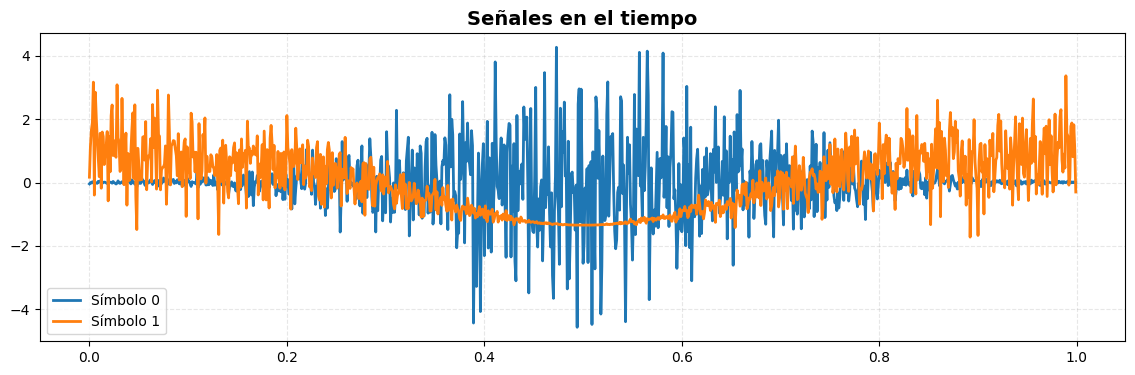

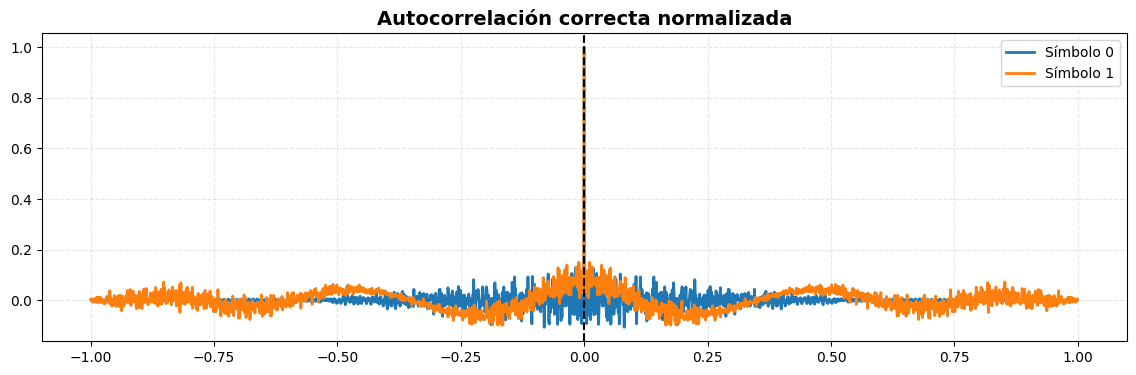

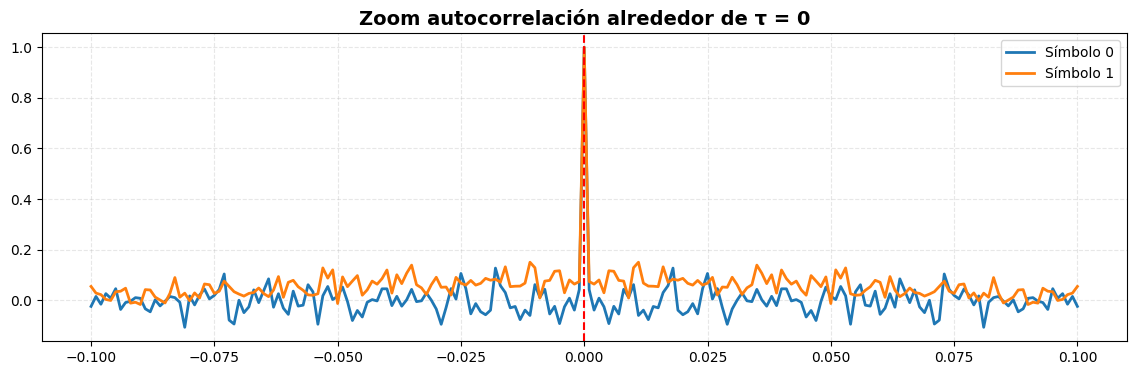

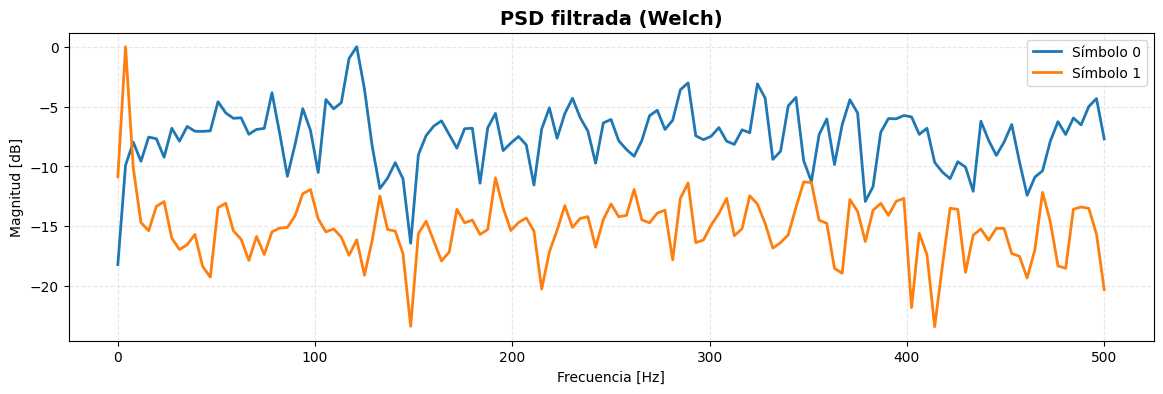

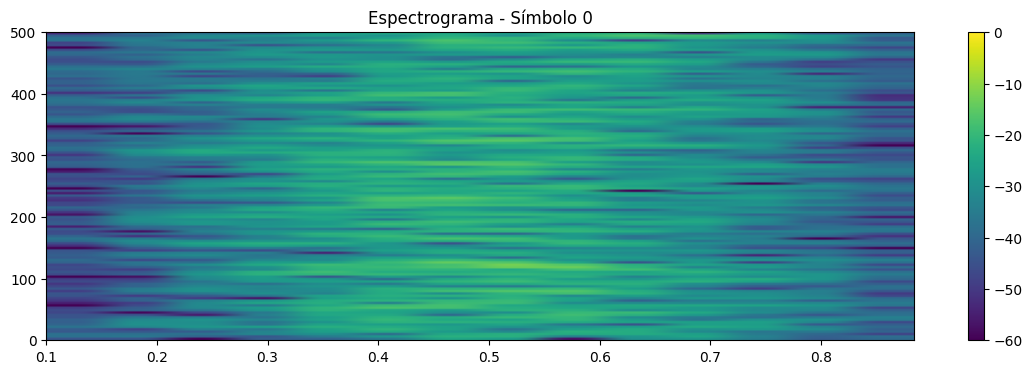

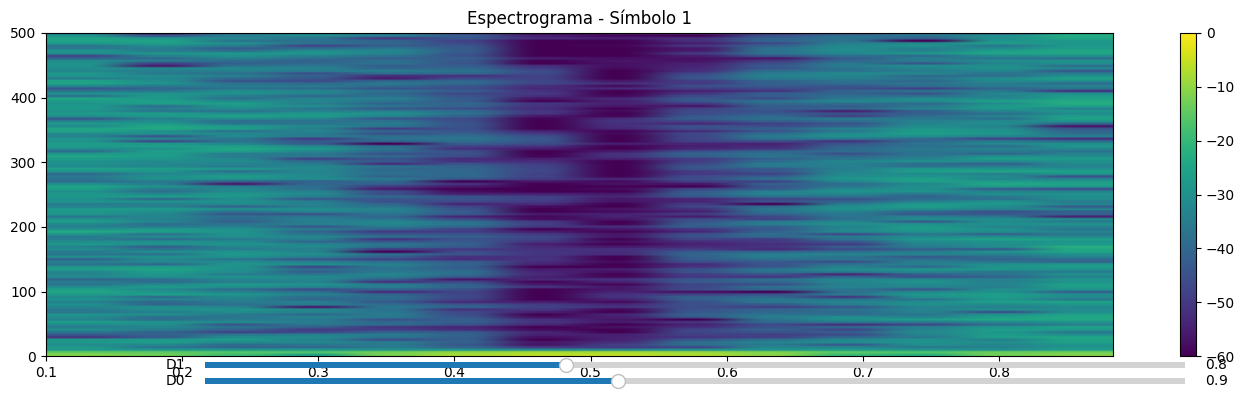

In [20]:
import torch
import math
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider
import numpy as np
from scipy.signal import welch

# ================= CONFIGURACIÓN =================
device = torch.device("cpu")
torch.set_default_dtype(torch.float64)
torch.manual_seed(0)

Fs = 1000.0
T_symbol = 1.0
N = int(Fs * T_symbol)
Ts = 1/Fs
t = torch.arange(0, N, device=device) * Ts

# Envolventes
center = T_symbol/2
sigma_env = T_symbol/6
env0 = torch.exp(-0.5*((t-center)/sigma_env)**2)
env0 /= env0.max()
env1 = 1.0 - env0

# ================= GENERACIÓN DE SEÑALES =================
def generate_symbol0(D0_val):
    symbol0 = torch.randn(N, device=device) * D0_val * env0
    symbol0 = (symbol0 - symbol0.mean()) / symbol0.std()
    return symbol0

def generate_symbol1(D1_val):
    symbol1 = (D1_val - torch.randn(N, device=device) * 0.3) * env1
    symbol1 = (symbol1 - symbol1.mean()) / symbol1.std()
    return symbol1

# ================= PROFE: ELIMINAR COMPONENTE SENO =================
def quitar_seno_dominante(x):
    N = len(x)
    X = torch.fft.rfft(x)
    mags = torch.abs(X)

    # Ignorar DC → buscar el pico real
    fundamental = torch.argmax(mags[1:]) + 1
    X[fundamental] = 0  # eliminar ese seno

    return torch.fft.irfft(X, n=N)

# ================= AUTOCORRELACIÓN CORRECTA (FFT) =================
def autocorrelation_correcta(x):
    x = x - x.mean()                # quitar DC
    Xf = torch.fft.fft(x, n=2*N-1)
    R = torch.fft.ifft(Xf * torch.conj(Xf)).real
    R = torch.fft.fftshift(R)
    R = R / R.max()                 # normalizar en R(0)
    lags = torch.arange(-(N-1), N, device=x.device) * Ts
    return R, lags

def compute_autocorr(symbol):
    symbol = quitar_seno_dominante(symbol)
    R, lags = autocorrelation_correcta(symbol)
    return R, lags

# ================= PSD FILTRADA (MÉTODO WELCH) =================
def compute_psd(symbol):
    f, Pxx = welch(symbol.cpu().numpy(), fs=Fs, nperseg=256)
    Pxx_db = 10*np.log10(Pxx / Pxx.max())
    return f, Pxx_db


# ================= CONFIGURACIÓN INICIAL =================
D0_init = 0.9
D1_init = 0.8

symbol0 = generate_symbol0(D0_init)
symbol1 = generate_symbol1(D1_init)

R0, lags = compute_autocorr(symbol0)
R1, _ = compute_autocorr(symbol1)

f0, S0_db = compute_psd(symbol0)
f1, S1_db = compute_psd(symbol1)


# ================= FIGURAS =================
# --- TIEMPO ---
fig_time, ax_time = plt.subplots(figsize=(14,4))
line0_time, = ax_time.plot(t.cpu(), symbol0.cpu(), label="Símbolo 0", linewidth=2)
line1_time, = ax_time.plot(t.cpu(), symbol1.cpu(), label="Símbolo 1", linewidth=2)
ax_time.set_title("Señales en el tiempo", fontsize=14, fontweight='bold')
ax_time.grid(True, linestyle="--", alpha=0.3)
ax_time.legend()

# --- AUTOCORRELACIÓN ---
fig_corr, ax_corr = plt.subplots(figsize=(14,4))
line0_corr, = ax_corr.plot(lags.cpu(), R0.cpu(), label="Símbolo 0", linewidth=2)
line1_corr, = ax_corr.plot(lags.cpu(), R1.cpu(), label="Símbolo 1", linewidth=2)
ax_corr.axvline(0, color="black", linestyle="--", linewidth=1.5)
ax_corr.set_title("Autocorrelación correcta normalizada", fontsize=14, fontweight='bold')
ax_corr.grid(True, linestyle="--", alpha=0.3)
ax_corr.legend()

# --- ZOOM τ=0 ---
zoom_range = 0.1
mask_zoom = (lags>=-zoom_range)&(lags<=zoom_range)
fig_zoom, ax_zoom = plt.subplots(figsize=(14,4))
line0_zoom, = ax_zoom.plot(lags[mask_zoom].cpu(), R0[mask_zoom].cpu(), label="Símbolo 0", linewidth=2)
line1_zoom, = ax_zoom.plot(lags[mask_zoom].cpu(), R1[mask_zoom].cpu(), label="Símbolo 1", linewidth=2)
ax_zoom.axvline(0,color='red',linestyle='--',linewidth=1.5)
ax_zoom.set_title("Zoom autocorrelación alrededor de τ = 0", fontsize=14, fontweight='bold')
ax_zoom.grid(True, linestyle="--", alpha=0.3)
ax_zoom.legend()


# --- PSD FILTRADA ---
fig_fft, ax_fft = plt.subplots(figsize=(14,4))
line0_fft, = ax_fft.plot(f0, S0_db, label="Símbolo 0", linewidth=2)
line1_fft, = ax_fft.plot(f1, S1_db, label="Símbolo 1", linewidth=2)
ax_fft.set_title("PSD filtrada (Welch)", fontsize=14, fontweight='bold')
ax_fft.set_xlabel("Frecuencia [Hz]")
ax_fft.set_ylabel("Magnitud [dB]")
ax_fft.grid(True, linestyle="--", alpha=0.3)
ax_fft.legend()


# --- ESPECTROGRAMA SÍMBOLO 0 ---
fig_spec0, ax_spec0 = plt.subplots(figsize=(14,4))
spec0 = ax_spec0.specgram(symbol0.cpu().numpy(), Fs=Fs, NFFT=256, noverlap=200,
                          cmap='viridis', scale='dB', vmin=-60, vmax=0)
plt.colorbar(spec0[3], ax=ax_spec0)
ax_spec0.set_title("Espectrograma - Símbolo 0")


# --- ESPECTROGRAMA SÍMBOLO 1 ---
fig_spec1, ax_spec1 = plt.subplots(figsize=(14,4))
spec1 = ax_spec1.specgram(symbol1.cpu().numpy(), Fs=Fs, NFFT=256, noverlap=200,
                          cmap='viridis', scale='dB', vmin=-60, vmax=0)
plt.colorbar(spec1[3], ax=ax_spec1)
ax_spec1.set_title("Espectrograma - Símbolo 1")


plt.tight_layout()


# ================= SLIDERS =================
ax_D0 = plt.axes([0.15,0.02,0.7,0.03])
slider_D0 = Slider(ax_D0, 'D0', 0.1, 2.0, valinit=D0_init, valstep=0.05)

ax_D1 = plt.axes([0.15,0.06,0.7,0.03])
slider_D1 = Slider(ax_D1, 'D1', 0.1, 2.0, valinit=D1_init, valstep=0.05)


# ================= ACTUALIZACIÓN =================
def update(val):
    D0_val = slider_D0.val
    D1_val = slider_D1.val

    # --- SÍMBOLO 0 ---
    s0 = generate_symbol0(D0_val)
    line0_time.set_ydata(s0.cpu())

    R0_new, _ = compute_autocorr(s0)
    line0_corr.set_ydata(R0_new.cpu())
    line0_zoom.set_ydata(R0_new[mask_zoom].cpu())

    f0_new, S0_new = compute_psd(s0)
    line0_fft.set_ydata(S0_new)

    ax_spec0.cla()
    ax_spec0.specgram(s0.cpu().numpy(), Fs=Fs, NFFT=256, noverlap=200,
                      cmap='viridis', scale='dB', vmin=-60, vmax=0)
    ax_spec0.set_title("Espectrograma - Símbolo 0")

    # --- SÍMBOLO 1 ---
    s1 = generate_symbol1(D1_val)
    line1_time.set_ydata(s1.cpu())

    R1_new, _ = compute_autocorr(s1)
    line1_corr.set_ydata(R1_new.cpu())
    line1_zoom.set_ydata(R1_new[mask_zoom].cpu())

    f1_new, S1_new = compute_psd(s1)
    line1_fft.set_ydata(S1_new)

    ax_spec1.cla()
    ax_spec1.specgram(s1.cpu().numpy(), Fs=Fs, NFFT=256, noverlap=200,
                      cmap='viridis', scale='dB', vmin=-60, vmax=0)
    ax_spec1.set_title("Espectrograma - Símbolo 1")

    fig_time.canvas.draw_idle()
    fig_corr.canvas.draw_idle()
    fig_zoom.canvas.draw_idle()
    fig_fft.canvas.draw_idle()
    fig_spec0.canvas.draw_idle()
    fig_spec1.canvas.draw_idle()

slider_D0.on_changed(update)
slider_D1.on_changed(update)

plt.show()
